# Kaplan-Meier Baseline

Population-level survival curves stratified by ApoE4, sex, and baseline diagnosis.
No model fitting — pure non-parametric reference for the time-to-MCI→AD distribution.

Outputs are saved to `_artifacts_/km_*.png` and `_artifacts_/km_curves.json`.

In [1]:
import sys, json, os
from pathlib import Path

REPO_ROOT = Path('/mnt/e/fyassine/ad-early-detection')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

from PROGNOSER.common.survival_table import build_survival_table

sns.set_theme(style='whitegrid')
ARTIFACTS = Path(__file__).parent / '_artifacts_' if '__file__' in globals() else Path('_artifacts_')
ARTIFACTS = (REPO_ROOT / 'PROGNOSER' / 'notebooks' / '_artifacts_')
ARTIFACTS.mkdir(parents=True, exist_ok=True)
print('Artifacts dir:', ARTIFACTS)

Artifacts dir: /mnt/e/fyassine/ad-early-detection/PROGNOSER/notebooks/_artifacts_


In [ ]:
from DATA.src.splitting.load_splits import splits_dir
COHORTS_CSV = REPO_ROOT / 'DATA' / 'DELCODE' / '__fc_wholebrain_sch200_flat__' / 'metadata' / 'cohorts.csv'
SPLITS_DIR = splits_dir('downstream')

# Build full at-risk table (all converters + non-converter MCI in cohorts.csv)
table_full = build_survival_table(str(COHORTS_CSV))
print(f'Full at-risk pool: n={len(table_full)}, events={int(table_full.event_observed.sum())}')
print(f'Event rate: {table_full.event_observed.mean():.1%}')
print(f'Duration range: {table_full.duration.min():.0f} - {table_full.duration.max():.0f} months')
table_full.head()

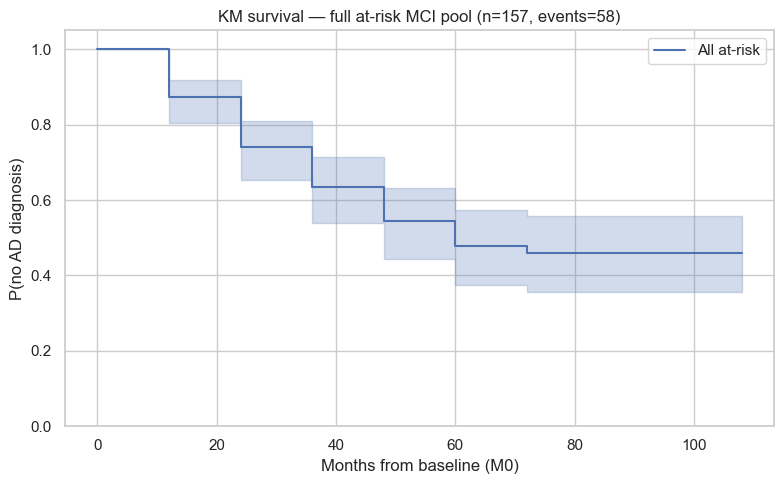

Median survival: 60.0 months


In [3]:
kmf = KaplanMeierFitter()
kmf.fit(table_full['duration'], event_observed=table_full['event_observed'], label='All at-risk')

fig, ax = plt.subplots(figsize=(8, 5))
kmf.plot_survival_function(ax=ax, ci_show=True)
ax.set_xlabel('Months from baseline (M0)')
ax.set_ylabel('P(no AD diagnosis)')
ax.set_title(f'KM survival — full at-risk MCI pool (n={len(table_full)}, events={int(table_full.event_observed.sum())})')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(ARTIFACTS / 'km_overall.png', dpi=150)
plt.show()
print(f'Median survival: {kmf.median_survival_time_:.1f} months')

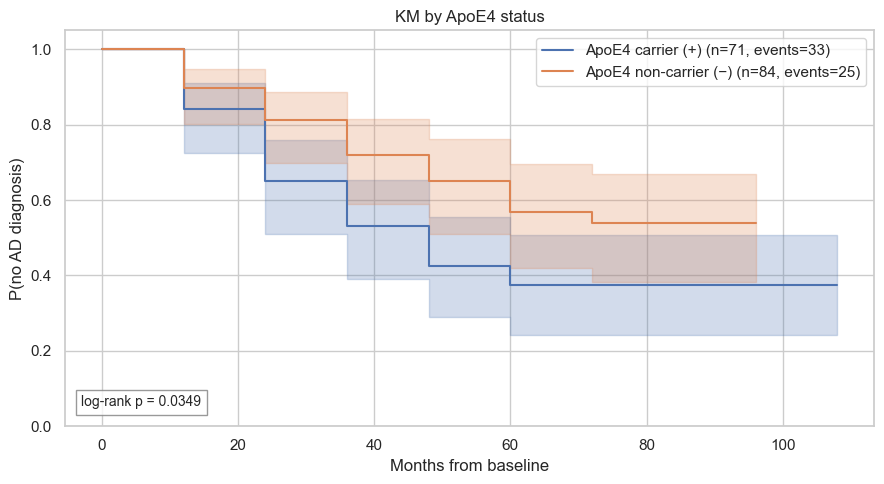

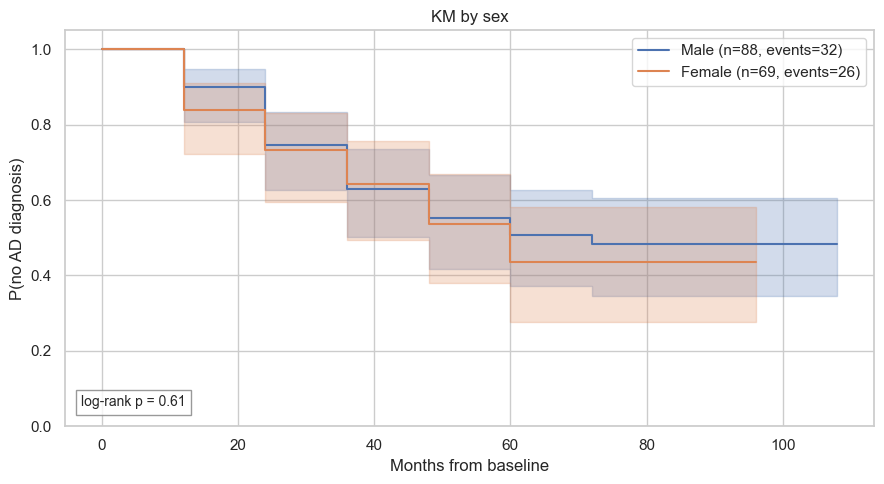

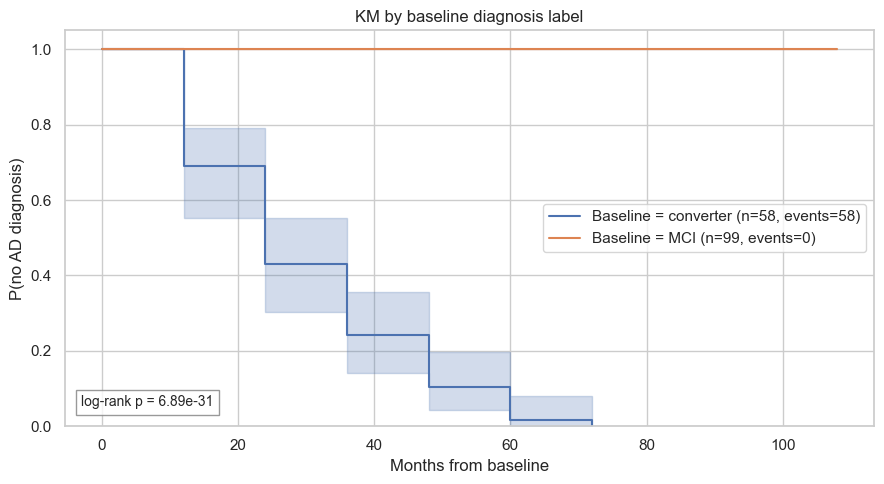

In [4]:
def plot_strata(table, group_col, group_labels, title, fname, min_n=3):
    fig, ax = plt.subplots(figsize=(9, 5))
    curves = []
    for value, label in group_labels.items():
        sub = table[table[group_col] == value]
        if len(sub) < min_n:
            continue
        k = KaplanMeierFitter()
        k.fit(sub['duration'], event_observed=sub['event_observed'], label=f'{label} (n={len(sub)}, events={int(sub.event_observed.sum())})')
        k.plot_survival_function(ax=ax, ci_show=True)
        curves.append((label, k))

    # log-rank between strata
    sub_all = table[table[group_col].isin(group_labels.keys())].dropna(subset=[group_col])
    if sub_all[group_col].nunique() >= 2:
        lr = multivariate_logrank_test(
            sub_all['duration'], sub_all[group_col], sub_all['event_observed']
        )
        ax.text(0.02, 0.05, f'log-rank p = {lr.p_value:.3g}', transform=ax.transAxes, fontsize=10,
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    ax.set_xlabel('Months from baseline')
    ax.set_ylabel('P(no AD diagnosis)')
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(ARTIFACTS / fname, dpi=150)
    plt.show()
    return curves

_ = plot_strata(
    table_full, 'apoe4',
    {1: 'ApoE4 carrier (+)', 0: 'ApoE4 non-carrier (−)'},
    'KM by ApoE4 status', 'km_by_apoe4.png',
)
_ = plot_strata(
    table_full, 'sex',
    {1: 'Male', 0: 'Female'},
    'KM by sex', 'km_by_sex.png',
)
_ = plot_strata(
    table_full, 'baseline_diagnosis',
    {'converter': 'Baseline = converter', 'mci': 'Baseline = MCI'},
    'KM by baseline diagnosis label', 'km_by_baseline_diagnosis.png',
)

In [5]:
kmf_overall = KaplanMeierFitter().fit(table_full['duration'], event_observed=table_full['event_observed'])
summary = {
    'n_total': int(len(table_full)),
    'n_events': int(table_full.event_observed.sum()),
    'event_rate': float(table_full.event_observed.mean()),
    'median_survival_months': float(kmf_overall.median_survival_time_) if not np.isnan(kmf_overall.median_survival_time_) else None,
    'duration_min_months': float(table_full.duration.min()),
    'duration_max_months': float(table_full.duration.max()),
    'timeline': kmf_overall.survival_function_.index.tolist(),
    'survival': kmf_overall.survival_function_.iloc[:, 0].tolist(),
}
with open(ARTIFACTS / 'km_curves.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Saved:', ARTIFACTS / 'km_curves.json')
print(f'Median time-to-conversion: {summary["median_survival_months"]} months')

Saved: /mnt/e/fyassine/ad-early-detection/PROGNOSER/notebooks/_artifacts_/km_curves.json
Median time-to-conversion: 60.0 months
